# Калибровка модели Nelson-Siegel-Svensson (NSS)

## Ссылки на статьи на эту тему (есть в репо):
1. По применение *Differential evolution* - Gilli, M., Große, S., & Schumann, E. (2010). "Calibrating the Nelson–Siegel–Svensson model
2. По применению *Ridge Resgreeion* Annaert, J., Claes, A. G., De Ceuster, M. J., & Zhang, H. (2013). "Estimating the spot rate curve using the Nelson–Siegel model: A ridge regression approach"

## ООП подход

Для того, чтобы можно было легко посмотреть как работает модель на своих данных в нотбуке реализован Class NSSModel. Его экемляры - это ваши эмитенты с рыночными данными на заданную дату. Демонстрация работы методов представлена в конце нотбука.

In [171]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.linalg import lstsq
import plotly.graph_objects as go

# Декоратор для добавления методов в класс
def add_method(cls):
    """
    Позволяет добавлять методы в уже существующий класс.
    Использование: @add_method(ИмяКласса)
    """
    def decorator(func):
        setattr(cls, func.__name__, func)
        return func
    return decorator

class NSSModel:
    def __init__(self):
        self.tau = None   # Нелинейные параметры
        self.beta = None  # Линейные параметры
        self.rmse = None  # Ошибка модели (добавляем сразу!)
        self.fitted = False

    def __repr__(self):
        status = "Fitted" if self.fitted else "Not Fitted"
        rmse_str = f", RMSE={self.rmse:.4f}" if self.rmse is not None else ""
        return f"NSSModel ({status}{rmse_str})"

## Модель NSS и разложеие по факторам

Модель NSS описывает доходность $y(t)$ как сумму четырех компонентов (факторов).
Формула выглядит так:

$$
y(t) = \beta_0 + \beta_1 \frac{1-e^{-t/\tau_1}}{t/\tau_1} + \beta_2 \left(\frac{1-e^{-t/\tau_1}}{t/\tau_1} - e^{-t/\tau_1}\right) + \beta_3 \left(\frac{1-e^{-t/\tau_2}}{t/\tau_2} - e^{-t/\tau_2}\right)
$$

### Значения параметров (**факторов**):
*   **$\beta_0, \beta_1, \beta_2, \beta_3$ (Linear parameters):**
    *   $\beta_0$: Долгосрочный уровень (Level).
    *   $\beta_1$: Наклон кривой (Slope).
    *   $\beta_2, \beta_3$: Искривления ("горбы") на разных сроках (Curvature).
    *   *Измеряются в % (процентах доходности), так как это линейные компоненты функции самой доходности*
*   **$\tau_1, \tau_2$ (Non-linear parameters):**
    *   Коэффициенты затухания. Определяют, **где** (на каком сроке) находятся горбы кривизны.
    *   *Измеряются в годах (Years).*

Далее реализована функция, которая строит матрицу факторов $X$ для заданных $\tau$.

In [172]:
@add_method(NSSModel)
def _nss_factors(self, t, tau1, tau2):
    """
    Считает матрицу факторов (Level, Slope, Curvature1, Curvature2).
    """
    # Защита от деления на ноль
    tau1 = np.maximum(tau1, 1e-4)
    tau2 = np.maximum(tau2, 1e-4)

    # Beta0: Level
    f0 = np.ones_like(t)

    # Beta1: Slope
    exp1 = np.exp(-t / tau1)
    f1 = (1 - exp1) / (t / tau1)

    # Beta2: Curvature 1
    f2 = f1 - exp1

    # Beta3: Curvature 2
    exp2 = np.exp(-t / tau2)
    f3 = (1 - exp2) / (t / tau2) - exp2

    return np.column_stack([f0, f1, f2, f3])

## Функция потерь и Оптимизация

Здесь используется **гибридный подход (Variable Projection)**:

1.  **Внешний цикл (Нелинейный):** Оптимизатор (Differential Evolution) перебирает пары $\tau_1, \tau_2$.
2.  **Внутренний цикл (Линейный):** Для фиксированных $\tau$, параметры $\beta$ находятся аналитически через **Ridge Regression** (МНК с регуляризацией).

Это позволяет свести задачу поиска 6 параметров к поиску всего 2 параметров

Также мы можем построить график ошибки (RMSE) в зависимости от $\tau_1$ и $\tau_2$.

### Справка по Ridge Regression

**[Ridge Regression](https://en.wikipedia.org/wiki/Ridge_regression)** — это метод настройки линейной модели (например, нашей NSS), который помогает бороться с **переобучением** и нестабильностью решения.

#### Проблема обычного МНК (OLS):
В обычной регрессии мы минимизируем только ошибку предсказания:

$$\text{Loss} = \sum (y_{fact} - y_{pred})^2 $$

Если данные "шумные" или параметры сильно коррелируют как наш $\beta $ и $\tau$ в модели NSS, обычный метод может выдать **гигантские коэффициенты** (например, $\beta_1 = 10000, \beta_2 = -9995$. Модель идеально пройдет через точки, но сломается на новых данных.

#### Как работает Ridge:
Ridge добавляет в формулу **штраф** за слишком большие коэффициенты. Мы теперь минимизируем:
$$\text{Loss}_{Ridge} = \sum (y_{fact} - y_{pred})^2 + \alpha \sum \beta_i^2 $$

Где:
*   $\alpha$ (или $ \lambda $) — сила регуляризации.
*   Если $\alpha = 0$ — это обычная регрессия.
*   Если \$\alpha$ очень большая — все коэффициенты стремятся к нулю (линия становится плоской).

#### Зачем это нам в NSS?
Модель Нельсона-Сигеля часто страдает от мультиколлинеарности (разные наборы параметров дают почти одинаковую кривую). Ridge-регрессия "успокаивает" коэффициенты $\beta$, делая кривую более гладкой и устойчивой, не давая ей принимать экстремальные формы ради одной случайной точки.

### Справка по Differential Evolution

**[Differential Evolution](https://en.wikipedia.org/wiki/Differential_evolution) (DE)** — это алгоритм **глобальной оптимизации**, который ищет минимум функции, имитируя процесс биологической эволюции.

#### Как работает Differential Evolution:
Вместо одной точки алгоритм использует целую **популяцию** решений набор векторов $\tau$.

1.  **Мутация (Mutation):** Алгоритм берет три случайных вектора из популяции  $a$,$b$,$c$ и создает "мутанта" по формуле:
    
  $$a + F \cdot (b - c)$$
  где $F$ — сила мутации. Это позволяет "прыгать" в случайные, но перспективные стороны.
    
2.  **Скрещивание (Crossover):** "Мутант" смешивается с текущим лучшим вектором.
    
3.  **Отбор (Selection):** Если "ребенок" оказался лучше "родителя" (ошибка меньше), он заменяет родителя в следующем поколении.

#### Почему можно использовать NSS?
DE не требует гладкости функции и не застревает в локальных минимумах так легко, как градиентные методы. Он "ощупывает" всю поверхность ошибок одновременно множеством агентов.

### Параметры в `scipy.optimize`:
*   `strategy='best1bin'` — классическая стратегия (берем лучшего + разницу двух случайных).
*   `popsize=15` — размер популяции (множитель для количества переменных). Для двух \(\tau\) это значит \(15 \times 2 = 30\) агентов.
*   `tol` — точность, при достижении которой поиск прекращается.

Чтобы посмотреть поверхность ошибок, на которой алгоритм ищет минимум функции можно использовать метод **plot_error_surface**


## Objective function

In [173]:
@add_method(NSSModel)
def _objective(self, taus, t, y, lambda_reg=0.001):
    """
    tau ищем перебором, а beta — через МНК (OLS).
    """
    tau1, tau2 = taus

    # Строим матрицу X для текущих tau
    X = self._nss_factors(t, tau1, tau2)

    # Находим Beta через Ridge Regression
    n_features = X.shape[1]
    # Добавляем фиктивные уравнения: sqrt(lambda)*beta = 0
    X_reg = np.vstack([X, np.sqrt(lambda_reg) * np.eye(n_features)])
    y_reg = np.concatenate([y, np.zeros(n_features)])

    # Решаем систему
    beta, _, _, _ = lstsq(X_reg, y_reg)

    # Считаем ошибку прогноза
    y_pred = X @ beta
    rmse = np.sqrt(np.mean((y - y_pred)**2))

    return rmse # Возвращаем RMSE

## Fitting

In [174]:
@add_method(NSSModel)
def fit(self, t, y, bounds=None, lambda_reg = 0.001):
    if bounds is None:
        bounds = [(0.1, 15), (0.1, 20)]

    print("Калибровка...")

    # Ищем лучшие tau1, tau2
    result = differential_evolution(
        self._objective,
        bounds,
        args=(t, y),
        strategy='best1bin',
        popsize=20,
        tol=1e-5,
        seed=42
    )

    self.tau = result.x

    # Восстанавливаем Beta для лучших Tau
    X_final = self._nss_factors(t, self.tau[0], self.tau[1])
    # Тот же Ridge, что и внутри objective
    X_reg = np.vstack([X_final, np.sqrt(lambda_reg) * np.eye(4)])
    y_reg = np.concatenate([y, np.zeros(4)])
    self.beta, _, _, _ = lstsq(X_reg, y_reg)
    self.fitted = True
    print(f"RMSE: {result.fun:.5f}")
    print(f"tau: {self.tau}")
    print(f"beta: {self.beta}")
    return self

#to check the final smooth curve
@add_method(NSSModel)
def predict(self, t):
    if not self.fitted: return None
    if np.ndim(t) == 0: t = np.array([t])

    X = self._nss_factors(t, self.tau[0], self.tau[1])
    return X @ self.beta


## Visualization

### Curve plotting

In [175]:
@add_method(NSSModel)
def plot_curve(self, t_market, y_market):
    t_smooth = np.linspace(0.1, max(t_market) + 10, 200)
    y_smooth = self.predict(t_smooth)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(t_market, y_market, color='red', s=50, label='Рынок', zorder=5)
    ax.plot(t_smooth, y_smooth, label='NSS Модель', linewidth=2)

    ax.set_title("Откалиброванная кривая доходности")
    ax.set_ylabel("Доходность (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

### Residual plotting

In [176]:
@add_method(NSSModel)
def plot_residuals(self, t_market, y_market):
    y_pred = self.predict(t_market)
    residuals = y_market - y_pred

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.bar(t_market, residuals, width=0.1, color='gray', alpha=0.6)
    ax.axhline(0, color='black')

    ax.set_title("Ошибка калибровки (Residuals)")
    ax.set_ylabel("Ошибка (б.п.)")
    ax.set_xlabel("Дюрация (лет)")
    ax.grid(True, alpha=0.3)
    plt.show()

### Error surface (for optimization)

In [177]:
@add_method(NSSModel)
def plot_error_surface(self, t, y, t1_range=(0.1, 10), t2_range=(0.1, 15), points=40):

    t1_vals = np.linspace(t1_range[0], t1_range[1], points)
    t2_vals = np.linspace(t2_range[0], t2_range[1], points)
    T1, T2 = np.meshgrid(t1_vals, t2_vals)
    Z = np.zeros_like(T1)

    for i in range(len(t1_vals)):
        for j in range(len(t2_vals)):
            Z[j, i] = self._objective([T1[j, i], T2[j, i]], t, y)

    fig = go.Figure(data=[
        go.Surface(z=Z, x=T1, y=T2, colorscale='Viridis', opacity=0.9, name='RMSE Landscape')
    ])

    # Просто проверяем, обучена ли модель. Поле rmse гарантированно существует.
    if self.fitted and self.rmse is not None:
        fig.add_trace(go.Scatter3d(
            x=[self.tau[0]],
            y=[self.tau[1]],
            z=[self.rmse], # Теперь это безопасно
            mode='markers',
            marker=dict(size=5, color='red', symbol='circle'),
            name=f'Found Minimum (RMSE={self.rmse:.4f})'
        ))

    fig.update_layout(
        title='RMSE = f(tau1, tau2)',
        scene=dict(
            xaxis_title='Tau 1',
            yaxis_title='Tau 2',
            zaxis_title='RMSE'
        ),
        width=900, height=600,
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

## Tests

### Газпромбанк

In [179]:
# market_data - Газпром 2/2/26
t_data = np.array([0.69, 1.28, 1.96, 2.21, 3.23]) #durations (years)
y_data = np.array([15.54, 15.82, 15.01, 16.33, 16.23]) #yields

gpb = NSSModel()
gpb.fit(t_data, y_data,lambda_reg=0.001)

Калибровка...
RMSE: 0.41641
tau: [0.86245298 5.99184879]
beta: [15.42584972  0.48791379 -2.12670908  5.81297432]


NSSModel (Fitted)

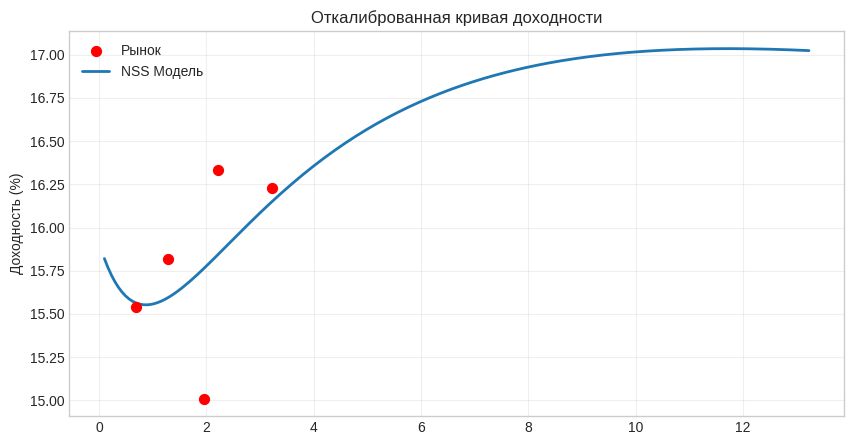

In [180]:
gpb.plot_curve(t_data, y_data)

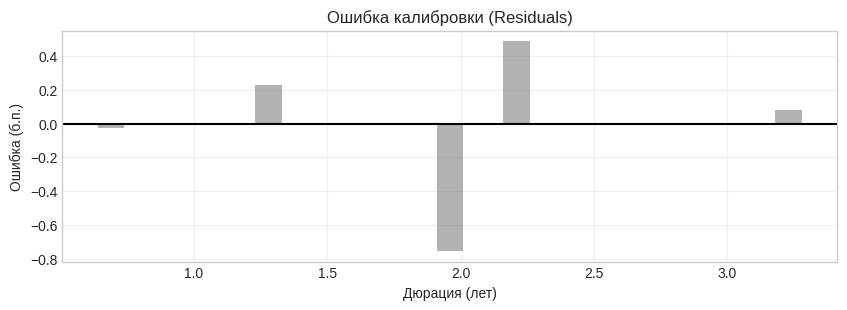

In [181]:
gpb.plot_residuals(t_data, y_data)

In [182]:
gpb.plot_error_surface(t_data, y_data)

### Роснефть

In [183]:
# market_data Роснефть 1/23/26
t_data = np.array([0.37, 1.18, 1.68, 1.85, 2.75, 3.00, 3.17])
y_data = np.array([16.05, 16.17, 15.16, 14.78, 12.65, 12.25, 11.72])

gpb = NSSModel()
gpb.fit(t_data, y_data,lambda_reg=0.001)

Калибровка...
RMSE: 0.06774
tau: [0.93317258 0.7653182 ]
beta: [ 3.57555064 10.68229096 10.14626637 12.1364727 ]


NSSModel (Fitted)

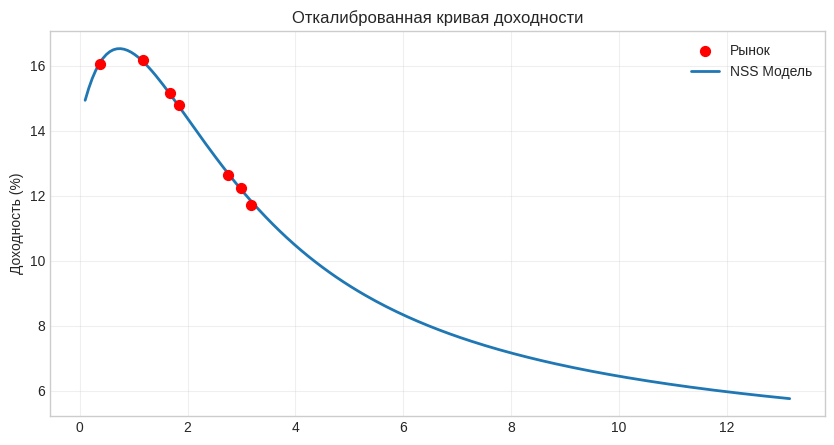

In [184]:
gpb.plot_curve(t_data, y_data)

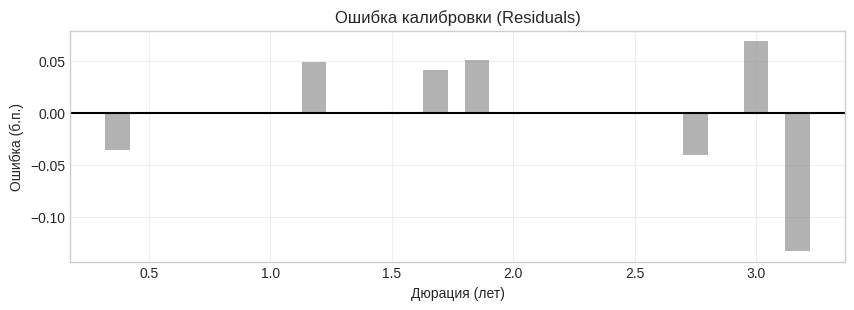

In [185]:
gpb.plot_residuals(t_data, y_data)

In [186]:
gpb.plot_error_surface(t_data, y_data)